# Python cheat sheet: an attempt to demystify our code

**ECU44291 Quantitative Macroeconomics.** Run All, then read down; change things and rerun.

Don't feel like you need to memorize this. Keep it open while you read code, and look things up when a line stops making sense. Every example is from our lecture code.

## Brackets, dots and symbols at a glance

The same symbol can mean different things. What is around it tells you which, so each symbol is listed with every place you will meet it in our code.

| You see | It means | Example: (as seen in our existing code) |
|---|---|---|
| **Round brackets** | | |
| `( )` right after a name | call a function, giving it these inputs | `np.linspace(0, 25, 300)` |
| `( )` around values with commas | a tuple: several values held as one | `figsize=(10, 4)` |
| **Square brackets** | | |
| `[ ]` right after a name | pick out an entry or entries | `p["beta"]`, `V[j + 1]` |
| `[ ]` on its own | a list | `assets = [0.0]` |
| **Curly braces** | | |
| `{ }` around `key: value` pairs | a dictionary: values stored under names | `{"r": 0.04, "w": 1.0}` |
| `{ }` inside `f"..."` | a slot, filled with a value | `f"growth {g}"` |
| **Colon** | | |
| `:` at the end of a line | an indented block follows | `for j in range(J):` |
| `:` between a key and a value | store this value under this name | `"n_a": 30` |
| `:` inside `[ ]` | a slice: a range of entries | `assets[:-1]`, `cons[20:40]` |
| `:` after `lambda` | inputs on the left, result on the right | `lambda x: x**2 - 2` |
| `:` inside the `{ }` of an f-string | formatting instructions follow | `{slope:.4f}` |
| **Stars** | | |
| `*` | multiply (arrays: entry by entry) | `beta * V[j + 1]` |
| `**` between numbers | power | `j**2` |
| `**` in front of a dictionary | all of its entries, poured in | `{**p, "n_a": 30}` |
| **Equals** | | |
| `=` | give a name to a value | `sol = solve_household_grid(p)` |
| `==` | ask whether two things are equal: `True` or `False` | `sigma == 1.0` |
| **Everything else** | | |
| `.` | something that belongs to what is on its left | `np.max`, `x.max()`, `sol["V"].shape` |
| `@` | matrix product (not `*`, which goes entry by entry) | `EV = P @ V` (Lecture 6) |
| `#` | a comment: Python ignores the rest of the line | `# last age first` |
| `;` | two statements on one line | `plt.legend(); plt.show()` |

**Putting it together:** `q = {**p, "n_a": 30}`. The `=` names the result `q`. The `{ }` makes a new dictionary. `**p` pours every entry of `p` into it, and `"n_a": 30` then stores 30 under `"n_a"`, replacing the 300 that came from `p`. So `q` is the lecture's parameters with one change, and `p` itself is untouched.

## Different in Python (read this if you have programmed before)

| | In Python | The trap |
|--|-----|-----|
| Blocks | **Indentation is the syntax.** No braces, no `end`. A `:` opens a block; the block is everything indented under it. | A line indented one level too little has left the loop. No error, a different program. |
| Counting | **From 0.** `x[0]` is the first entry, `x[-1]` the last. | R, MATLAB, Stata and Excel count from 1. |
| Ranges | **The end is not included.** `x[20:40]` is entries 20 to 39; `range(5)` is 0 to 4. | `np.linspace(0, 25, 300)` is the exception: it *does* include 25. |
| Powers | `**` is power: `j**2`. | `^` is not power. `2 ^ 3` is 1, with no error. |
| Names | `=` puts a second name on the same object; it does not copy. | `V_new = V`, then changing `V_new` changes `V`. Use `V.copy()`. |
| Arrays | `*` multiplies entry by entry; `@` is the matrix product. | The opposite of MATLAB, where `*` is the matrix product. |
| Several results | A function can return several values; `a, b = f()` names them. | |
| Parameters | Our models keep parameters in a dictionary: `p["beta"]`. | |
| Inputs by name | `bisection(f, 0, 1, tol=1e-10)`: named inputs, in any order, after the unnamed ones. | |
| Words | `True`, `False`, `None` take capitals. | `true` is a `NameError`. |
| Whole numbers | An array made with `dtype=int` holds only whole numbers. | Put 0.7 into one and it silently becomes 0. |
| Notebooks | Cells run in the order **you ran them**, not the order on screen. | A notebook that works for you can fail on Run All. |

## 1. Notebooks

**Run All, from the top, before anything else.** A notebook remembers only what you have run. If you open a notebook and run a cell halfway down, Python has never seen the `import` at the top or the function defined three cells up.

**`NameError: name 'p' is not defined`** almost always means a cell above was not run. Run All fixes it.

**Restart** (the circular arrow in VS Code) wipes the notebook's memory. Do it, then Run All, whenever things stop making sense. If the notebook still works, it really works.

In [1]:
import numpy as np                    # numpy, called np from now on: arrays and maths
import matplotlib.pyplot as plt       # matplotlib's plotting part, called plt
from scipy.optimize import brentq     # one function from scipy, called by its own name

p = dict(J=60, J_R=45, beta=0.96, R=1.04, sigma=2.0, w=1.0, tau=0.0, repl=0.4, a_max=25.0, n_a=300)
print("ready")

ready


**`import numpy as np`** loads numpy and lets you call it `np`. Everything numpy has is then `np.` something: `np.linspace`, `np.log`, `np.max`. The `np.` says which library the function comes from. **`from scipy.optimize import brentq`** brings in one function, used without a prefix: `brentq(...)`.

## 2. Printing

**The simple way.** Give `print` anything, separated by commas. It writes them out with spaces between.

In [2]:
slope = 0.0123456
print("slope", slope)
print("slope", round(slope, 4))

slope 0.0123456
slope 0.0123


That is all you ever need. The rest of this section is for reading code that uses the fancier way.

### The f-string, taken apart

This line is from Tutorial 1:

In [3]:
beta, sigma, slope, predicted, peak = 0.9, 5.0, -0.0157, -0.0131, 3.7624
print(f"beta {beta}, sigma {sigma:.0f}: measured {slope:+.4f}, Euler says {predicted:+.4f}, peak assets {peak:5.2f}")

beta 0.9, sigma 5: measured -0.0157, Euler says -0.0131, peak assets  3.76


Piece by piece:

- `print( ... )`: show what is inside the round brackets. There is one input: the string.
- `f"..."`: the **`f` before the opening quote** makes this an f-string. Everything inside the quotes is printed as it is, **except** what is inside curly braces.
- `{beta}`: put the value of `beta` here.
- `{sigma:.0f}`: put `sigma` here, **formatted**. Everything after the colon is a formatting instruction. `.0f` means "a decimal number with 0 decimals", so `5.0` prints as `5`.
- `{slope:+.4f}`: `+` means always show the sign, `.4` means four decimals, `f` means a decimal number.
- `{peak:5.2f}`: `5` means at least 5 characters wide (padded with spaces on the left, so columns line up when you print several lines), `.2f` two decimals.

**The two `f`s are different things.** The one before the quote means "this string has slots". The one at the end of a slot's instructions means "show it as a decimal number" (it stands for *fixed-point*). The rule for a slot is always `{value:instructions}`, and the instructions are always optional.

| In the slot | Means | 0.0123456 shows as |
|---|---|---|
| `{x}` | as Python writes it | `0.0123456` |
| `{x:.2f}` | 2 decimals | `0.01` |
| `{x:.4f}` | 4 decimals | `0.0123` |
| `{x:+.4f}` | 4 decimals, sign always shown | `+0.0123` |
| `{x:10.4f}` | at least 10 characters wide | `␣␣␣␣0.0123` |
| `{x:.2e}` | scientific notation | `1.23e-02` |
| `{x:.1%}` | as a percentage, 1 decimal | `1.2%` |

**What you need:** `{x}` and `{x:.2f}`. Everything else is decoration. Anything can go inside the braces, including a calculation: `{assets.max():.2f}`.

## 3. Counting, slicing and loops

**Counting starts at 0, and a slice stops before its end.** Ages 21 to 80 are entries 0 to 59.

In [4]:
ages = 20 + np.arange(1, 61)          # 1, 2, ..., 60: the 61 is not included
print(ages[0], ages[1], ages[-1])     # first, second, last
print(ages[20:40])                    # entries 20 to 39: ages 41 to 60
print(len(ages), len(ages[:-1]))      # [:-1] is everything except the last entry

21 22 80
[41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60]
60 59


> **Python-specific.** `x[a:b]` runs from `a` up to but **not including** `b`, so `x[a:b]` has `b - a` entries. Leave out either end to go to the edge: `x[:5]` is the first five, `x[-5:]` the last five, `x[:-1]` all but the last. R and MATLAB count from 1 and include the end.

**Loops.** `for name in things:` runs the indented lines once for each thing, with `name` set to it. `range` makes the numbers to loop over.

In [5]:
for n in (30, 100, 300):              # loop over the values you list
    print("grid", n)

print(list(range(5)))                 # range(stop): 0 up to stop - 1
print(list(range(5, -1, -1)))         # range(start, stop, step): backwards; stop not included

grid 30
grid 100
grid 300
[0, 1, 2, 3, 4]
[5, 4, 3, 2, 1, 0]


`range(J - 1, -1, -1)` in the household solver is "from $J - 1$ down to $0$": the last age first, which is backward induction. The `-1` in the middle is where it stops (not included), so 0 is the last value.

**`enumerate`** gives you the position and the value together:

In [6]:
a = np.array([0.0, 0.5, 1.0])
for i, ai in enumerate(a):            # i is the position, ai the value at that position
    print(i, ai)

0 0.0
1 0.5
2 1.0


**A list comprehension** builds a list from a loop, in one line. These two do the same thing:

In [7]:
squares = []
for x in range(5):
    squares.append(x**2)              # .append adds one entry to the end of a list
print(squares)

squares = [x**2 for x in range(5)]    # the same, read as "x squared, for each x in range(5)"
print(squares)

[0, 1, 4, 9, 16]
[0, 1, 4, 9, 16]


## 4. Dictionaries: how our models carry their parameters

A dictionary stores values under names (**keys**). `p["beta"]` is "the value stored under `"beta"`". These two lines build the same dictionary:

In [8]:
p_short = dict(beta=0.96, sigma=2.0)          # dict(...) with name=value inputs
p_long = {"beta": 0.96, "sigma": 2.0}         # curly braces with "key": value pairs
print(p_short == p_long, p_long["beta"])

True 0.96


**Changing one parameter, keeping the rest:** `{**p, "n_a": 30}`. The `**p` pours every entry of `p` into the new dictionary; `"n_a": 30` then overwrites that one entry. `p` itself is not touched, so the lecture's household is always there to compare with.

In [9]:
q = {**p, "n_a": 30}
print(q["n_a"], p["n_a"])             # q has 30; p still has 300
print(list(q.keys()))                 # the keys: the names of everything stored

30 300
['J', 'J_R', 'beta', 'R', 'sigma', 'w', 'tau', 'repl', 'a_max', 'n_a']


A misspelt key is a **`KeyError`**: `p["Beta"]` and `p["na"]` both fail, because the keys are `"beta"` and `"n_a"`. The error message names the key it could not find.

## 5. Functions

`def` defines a function: its name, its inputs, and the indented block that runs when you call it. `return` hands the result back.

In [10]:
def utility(c, sigma=2.0):
    """CRRA utility; log utility when sigma is 1."""
    return np.log(c) if sigma == 1.0 else c ** (1 - sigma) / (1 - sigma)

print(utility(2.0))                   # sigma not given, so the default, 2.0, is used
print(utility(2.0, sigma=1.0))        # sigma given by name
print(utility(2.0, 1.0))              # the same, given by position

-0.5
0.6931471805599453
0.6931471805599453


Piece by piece:

- `sigma=2.0` in the `def` line is a **default**: used when the caller does not say.
- The text in triple quotes under the `def` line is a **docstring**: a description. `help(utility)` prints it.
- `A if condition else B` is a one-line if: `A` when the condition holds, otherwise `B`.

**Several results.** A function can return several values at once. The caller names them in order, on the left of the `=`:

In [11]:
def peak(assets, ages):
    return assets.max(), ages[assets.argmax()]

top, when = peak(np.array([0.0, 2.0, 1.0]), np.array([21, 22, 23]))
print(top, when)

2.0 22


> **Python-specific.** This is why `assets, cons = simulate_profile(sol, p)` works: the function returns two arrays, and the line names them. The same trick sets several names at once, as in the solver: `J, R, beta, sigma = p["J"], p["R"], p["beta"], p["sigma"]`.

**`lambda`** is a function in one line, with no name, for when another function needs a function as its input. These are the same:

In [12]:
def g(x):
    return x**2 - 2

print(brentq(g, 0, 2))                         # brentq finds where g is zero, between 0 and 2
print(brentq(lambda x: x**2 - 2, 0, 2))        # the same, without naming the function

1.4142135623731364
1.4142135623731364


## 6. Names, copies and whole numbers

> **Python-specific.** **`=` does not copy.** `V_new = V` puts a second name on the **same** array. Change one and you have changed both. This is the Lecture 4 bug where value function iteration "converges" in one sweep: the old and new value functions are the same object, so their distance is zero. Use `.copy()` when you need a separate array. (R copies when you change something; Python does not.)

In [13]:
V = np.zeros(3)
V_new = V                             # the same array, two names
V_new[0] = 5.0
print(V)                              # V has changed too

V = np.zeros(3)
V_new = V.copy()                      # a separate array
V_new[0] = 5.0
print(V)                              # V is untouched

[5. 0. 0.]
[0. 0. 0.]


> **Python-specific.** **Integer arrays keep only whole numbers, silently.** The grid solver stores its policy as grid **positions**, so it makes the array with `dtype=int`. If you later store asset **levels** in it, as a continuous-choice solver does, the decimals are thrown away with no error.

In [14]:
policy = np.zeros(3, dtype=int)
policy[0] = 0.7
print(policy)                         # 0.7 became 0

policy = np.zeros(3)                  # the default is decimal numbers (float)
policy[0] = 0.7
print(policy)

[0 0 0]
[0.7 0.  0. ]


## 7. NumPy arrays

An array is a block of numbers, all handled at once. Arithmetic works entry by entry, with no loop:

In [15]:
a = np.linspace(0.0, 2.0, 3)          # 3 evenly spaced points from 0 to 2, both ends included
print(a)
print(1.04 * a + 1.0)                 # every entry times 1.04, plus 1
print(a.shape, a.max(), a.argmax())   # shape, largest value, and the POSITION of it

[0. 1. 2.]
[1.   2.04 3.08]
(3,) 2.0 2


**`x.max()` and `np.max(x)` are the same thing.** The first is a **method**: a function that belongs to the array, called with a dot. Both styles appear in our code.

**`max` against `argmax`.** `max` gives the largest value; `argmax` gives **where** it is, as a position. To turn a position into something meaningful, use it to index: `ages[assets.argmax()]` is the age at which assets peak.

> **Python-specific.** `*` on arrays multiplies entry by entry. The matrix product is `@`, as in `EV = P @ V` in Lecture 6. In MATLAB it is the other way round (`*` is the matrix product, `.*` entry by entry).

### Two dimensions, and `[:, None]`

This is the line in the household solver that does all the work:

```python
c = R * a[:, None] + y[j] - a[None, :]     # rows: a today; columns: a' choices
```

It builds a **table**: consumption for every asset level today (rows) and every choice of assets tomorrow (columns). `a[:, None]` turns the grid into a column; `a[None, :]` turns it into a row. Adding a column to a row fills in a whole table: every row paired with every column. This is called **broadcasting**. On a grid of three points:

In [16]:
a = np.array([0.0, 1.0, 2.0])
print(a.shape, a[:, None].shape, a[None, :].shape)   # plain, column, row

c = 1.04 * a[:, None] + 1.0 - a[None, :]             # R = 1.04, income 1.0
print(c)                                             # row: a today; column: a' tomorrow

(3,) (3, 1) (1, 3)
[[ 1.    0.   -1.  ]
 [ 2.04  1.04  0.04]
 [ 3.08  2.08  1.08]]


Read row 0: with nothing today and income 1, choosing 0 tomorrow leaves 1 to consume; choosing 1 leaves 0; choosing 2 leaves $-1$, which is not possible.

**`c[i, k]`** is the entry in row `i`, column `k`. **`c[i]`** is the whole of row `i`. In the solver, `V[j + 1]` is the row of the value function for age $j + 1$.

**Masks: picking out the entries where something is true.** `c > 0` is a table of `True` and `False`. Indexing with it picks out the `True` entries. This is how the solver gives impossible choices a utility of $-\infty$, so they can never be chosen:

In [17]:
u = np.full(c.shape, -np.inf)          # a table the shape of c, every entry minus infinity
u[c > 0] = np.log(c[c > 0])            # only where consumption is positive: the log of it
print(c > 0)
print(u)

[[ True False False]
 [ True  True  True]
 [ True  True  True]]
[[ 0.                -inf        -inf]
 [ 0.71294981  0.03922071 -3.21887582]
 [ 1.1249296   0.73236789  0.07696104]]


**`axis=1`: along each row.** As in the solver, add the discounted value of each choice tomorrow to today's utility. Then `value.max(axis=1)` is the best value in each row, and `value.argmax(axis=1)` is **which column** it is in: the best choice for each asset level today. `axis=0` would go down each column instead.

In [18]:
V_next = np.array([0.0, 1.0, 1.5])     # a made-up value of arriving tomorrow with 0, 1 or 2
value = u + 0.96 * V_next[None, :]     # today's utility + discounted value tomorrow
best = value.argmax(axis=1)            # for each row: the position of the best choice
print(best)                            # positions, not asset levels
print(a[best])                         # the asset levels those positions stand for
print(value.max(axis=1))               # the best value in each row

[0 1 1]
[0. 1. 1.]
[0.         0.99922071 1.69236789]


## 8. Plotting

**One figure.** Every `plt.plot` adds a line to the current figure; `plt.show()` draws it. So a loop of `plt.plot` calls puts all the lines on one figure.

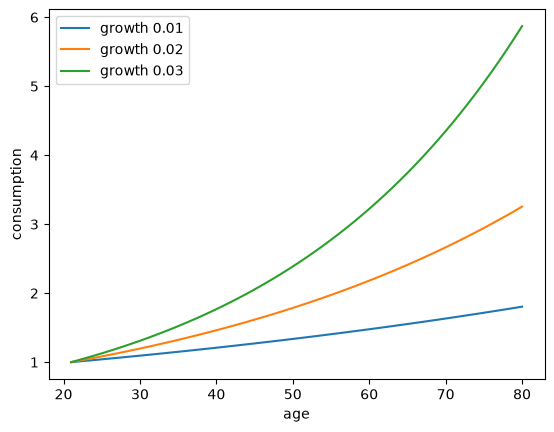

In [19]:
ages = 20 + np.arange(1, 61)
for g in (0.01, 0.02, 0.03):
    # label: this line's name in the key
    plt.plot(ages, np.exp(g * (ages - 21)), label=f"growth {g}")
plt.xlabel("age")
plt.ylabel("consumption")
plt.legend()                          # the key, built from the labels
plt.show()

`plt.plot(x, y)` needs `x` and `y` the **same length**. If not, the error says something like `x and y must have same first dimension, but have shapes (60,) and (61,)`. Assets have one more entry than ages (what is left at death), which is why our code plots `assets[:-1]`.

**Line styles:** a third input to `plot`. `"-"` solid, `"--"` dashed, `":"` dotted, `"o"` dots, `"o-"` dots joined by a line. Colours by name: `color="grey"`.

**Several panels.** `plt.subplots` makes a figure and its panels (**axes**) in one go, and returns both, so the line names both:

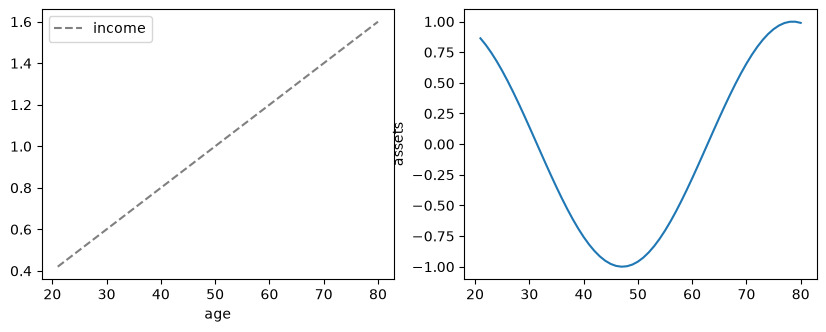

In [20]:
# 1 row of 2 panels; figsize is (width, height) in inches
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(ages, 0.02 * ages, "--", color="grey", label="income")
axes[0].set_xlabel("age")
axes[0].legend()
axes[1].plot(ages, np.sin(ages / 10))
axes[1].set_ylabel("assets")
plt.show()

> **Python-specific.** On a panel, most commands gain `set_`: `plt.xlabel` becomes `axes[0].set_xlabel`, `plt.title` becomes `ax.set_title`, `plt.xlim` becomes `ax.set_xlim`. But `plot` and `legend` keep their names. There is no logic to it; it is a historical accident in matplotlib. The rule: **one figure, use `plt.`; several panels, use `axes[i].` and add `set_` to the labels.**

## 9. Errors: read the last line first

The last line of an error names the problem. The lines above it say where it happened; find the last one that is in **your** file.

| Last line says | Usually means |
|---|---|
| `NameError: name 'p' is not defined` | a cell above was not run (Run All), or a typo in the name |
| `KeyError: 'na'` | a dictionary has no entry with that key: check the spelling (`"n_a"`) |
| `IndexError: index 60 is out of bounds for axis 0 with size 60` | counting from 0: the last entry of 60 is `x[59]`, or `x[-1]` |
| `ValueError: operands could not be broadcast together with shapes (60,) (61,)` | two arrays of different lengths in one calculation |
| `ValueError: x and y must have same first dimension` | `plt.plot` with `x` and `y` of different lengths |
| `TypeError: 'int' object is not subscriptable` | square brackets on a single number, not an array or dictionary |
| `IndentationError` | the spaces at the start of a line do not match the block it belongs to |
| `ModuleNotFoundError: No module named 'numpy'` | the notebook is on the wrong kernel: choose `.venv` at the top right |
| `ModuleNotFoundError: No module named 'solow'` | a test file run as a script: use `uv run pytest` from the project folder |

**Tests.** `assert condition` does nothing if the condition is true and stops with an `AssertionError` if it is false. `x == pytest.approx(y)` asks "equal, up to rounding", because decimal numbers are rarely exactly equal: `0.1 + 0.2 == 0.3` is `False`.

In [21]:
print(0.1 + 0.2 == 0.3, 0.1 + 0.2)
print(np.isclose(0.1 + 0.2, 0.3))      # "equal up to rounding", numpy's version

False 0.30000000000000004
True
